In [2]:
import requests
import pandas as pd 
import numpy as np 

In [3]:
api_key='b0b16ad6834c4ebea1b181e3afa92e21'
technical='time_series'
ticker='BTC/USD'
timezone='Asia/Calcutta'
interval='4h'

In [109]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()

In [115]:
from tensorflow import keras
from tensorflow.keras.layers import LSTM,Bidirectional,Dense,Dropout,BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
model=keras.Sequential([
    Bidirectional(LSTM(64,return_sequences=True),input_shape=(16,9)),
    Dropout(0.3),
    Bidirectional(LSTM(32,return_sequences=False)),
    Dropout(0.3),
    Dense(64,activation='relu'),
    BatchNormalization(),
    Dropout(0.2),   
    Dense(1,activation='sigmoid')
])
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
model.summary()

c:\Users\#samay\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_26                │ (None, 16, 128)        │        37,888 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_27                │ (None, 64)             │        41,216 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,585 (326.50 KB)

 Trainable params: 83,457 (326.00 KB)

 Non-trainable params: 128 (512.00 B)

In [86]:
def calculate_atr(data,period):
    tr1=data['high']-data['low']
    tr2=abs(data['high']-data['close'].shift(1))
    tr3=abs(data['low']-data['close'].shift(1))
    data['TR']=pd.concat([tr1,tr2,tr3],axis=1).max(axis=1)
    data['ATR']=data['TR'].ewm(alpha=1/period,adjust=False).mean()
    return data['ATR'] 

In [36]:
import time 
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
data=pd.DataFrame()
session=requests.Session()
retries=Retry(total=5,backoff_factor=1,status_forcelist=[429,500,502,503,504])
session.mount("https://",HTTPAdapter(max_retries=retries))
for y in range(2022,2026):
    start_date=f'{y}-01-01T00:00:00'
    end_date=f'{y}-12-31T00:00:00'
    api_url=f'https://api.twelvedata.com/{technical}?symbol={ticker}&order=asc&timezone={timezone}&start_date={start_date}&end_date={end_date}&interval={interval}&outputsize=5000&apikey={api_key}'
    while True:
        fetch=session.get(api_url).json()
        if "values" in fetch:
            df=pd.DataFrame(fetch['values'])
            data=pd.concat([df,data])
            time.sleep(0.1) 
            break
        elif "code" in fetch and fetch["code"]==429:
            print("Rate limit exceeded")
            time.sleep(15)
        else:
            print("API Error:",fetch)
            fetch=None
            break
data=pd.concat([df,data])
data['color']=np.where(data['close']>data['open'],1,0)
data['open']=pd.to_numeric(data['open'])
data['close']=pd.to_numeric(data['close'])
data['high']=pd.to_numeric(data['high'])
data['low']=pd.to_numeric(data['low'])
data['body']=(data['close']-data['open'])
data

,datetime,open,high,low,close,color,body
0,2025-01-01 01:30:00,94022.10000,94074.24000,93205.00000,93354.22000,0,-667.88000
1,2025-01-01 05:30:00,93347.59000,94321.25000,93281.63000,93635.54000,1,287.95000
2,2025-01-01 09:30:00,93635.54000,93708.79000,93305.54000,93478.85000,0,-156.69000
3,2025-01-01 13:30:00,93478.85000,93564.06000,92743.63000,93250.79000,0,-228.06000
4,2025-01-01 17:30:00,93250.79000,94289.00000,93172.42000,94225.28000,1,974.49000
...,...,...,...,...,...,...,...
2174,2022-12-30 05:30:00,16631.19922,16637.72070,16577.42969,16590.46094,0,-40.73828
2175,2022-12-30 09:30:00,16591.83984,16605.43945,16437.47070,16470.33008,0,-121.50976
2176,2022-12-30 13:30:00,16467.25000,16519.81055,16456.51953,16486.51953,1,19.26953
2177,2022-12-30 17:30:00,16486.38086,16565.86914,16352.41992,16547.76953,1,61.38867


In [37]:
data['datetime']=pd.to_datetime(data['datetime'])
missing_times=pd.date_range("2022-01-01 01:30", "2025-05-31 21:30", freq="240T").difference(data['datetime'])
missing_times

C:\Users\#samay\AppData\Local\Temp\ipykernel_34292\3678471436.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  missing_times=pd.date_range("2022-01-01 01:30", "2025-05-31 21:30", freq="240T").difference(data['datetime'])


DatetimeIndex(['2022-02-19 21:30:00', '2022-11-18 05:30:00',
               '2022-11-19 05:30:00', '2022-11-19 09:30:00',
               '2022-11-19 13:30:00', '2022-12-31 01:30:00',
               '2022-12-31 05:30:00', '2022-12-31 09:30:00',
               '2022-12-31 13:30:00', '2022-12-31 17:30:00',
               '2022-12-31 21:30:00', '2023-02-22 21:30:00',
               '2023-02-23 01:30:00', '2023-02-23 05:30:00',
               '2023-12-31 01:30:00', '2023-12-31 05:30:00',
               '2023-12-31 09:30:00', '2023-12-31 13:30:00',
               '2023-12-31 17:30:00', '2023-12-31 21:30:00',
               '2024-12-31 01:30:00', '2024-12-31 05:30:00',
               '2024-12-31 09:30:00', '2024-12-31 13:30:00',
               '2024-12-31 17:30:00', '2024-12-31 21:30:00'],
              dtype='datetime64[ns]', freq=None)

In [38]:
missing_times=pd.date_range(start="2022-02-19 21:30",end="2022-02-19 21:30",freq="4h")
missing_df=pd.DataFrame({
    "datetime":missing_times,
    "open":[39856.98047],
    "high":[40382.75],
    "low":[39464.60938],
    "close":[40218.44141],
    "color":[1.0],
    "body":[361.46094]
})
data=pd.concat([data,missing_df],ignore_index=True)

In [39]:
missing_times=pd.date_range(start="2022-11-18 05:30",end="2022-11-18 05:30",freq="4h")
missing_df=pd.DataFrame({
    "datetime":missing_times,
    "open":[16681.92969],
    "high":[16727.19922],
    "low":[16498.17969],
    "close":[16502.50977],
    "color":[0.0],
    "body":[-179.41992]
})
data=pd.concat([data,missing_df],ignore_index=True)

In [40]:
missing_times=pd.date_range(start="2022-11-19 05:30",end="2022-11-19 13:30",freq="4h")
missing_df=pd.DataFrame({
    "datetime":missing_times,
    "open":[16681.92969,16825.42969,16727.86914],
    "high":[16727.19922,16825.42969,16833.86914],
    "low":[16498.17969,16708.80078,16663.88086],
    "close":[16502.50977,16731.130860,16737.839840],
    "color":[0.0,0.0,1.0],
    "body":[-179.41992,-94.298830,9.970700]
})
data=pd.concat([data,missing_df],ignore_index=True)

In [41]:
missing_times=pd.date_range(start="2022-12-31 01:30",end="2022-12-31 21:30",freq="4h")
missing_df=pd.DataFrame({
    "datetime":missing_times,
    "open":[16604.13086,16631.19922,16591.83984,16467.25000,16486.38086,16547.73047],
    "high":[16643.61914,16637.72070,16605.43945,16519.81055,16565.86914,16569.63086],
    "low":[16553.22070,16577.42969,16437.47070,	16456.51953,16352.41992,16510.61914],
    "close":[16631.19922,16590.46094,16470.33008,16486.51953,16547.76953,16520.49023],
    "color":[1.0,0.0,0.0,1.0,1.0,0.0],
    "body":[27.06836,-40.73828,-121.50976,19.26953,61.38867,-27.24024]
})
data=pd.concat([data,missing_df],ignore_index=True)

In [42]:
missing_times=pd.date_range(start="2023-02-22 21:30",end="2023-02-23 05:30",freq="4h")
missing_df=pd.DataFrame({
    "datetime":missing_times,
    "open":[24563.85938,24607.72070,24452.98047],
    "high":[24746.90039,24642.88086,24474.51953],
    "low":[24301.529300,24159.859380,23873.009766],
    "close":[24595.960940,24451.900390,24200.099609],
    "color":[1.0,0.0,0.0],
    "body":[32.101560,-155.820310,-252.880861]
})
data=pd.concat([data,missing_df],ignore_index=True)

In [43]:
missing_times=pd.date_range(start="2023-12-31 01:30",end="2023-12-31 21:30",freq="4h")
missing_df=pd.DataFrame({
    "datetime":missing_times,
    "open":[42114.98,42064.22,41963.25,41925.29,41882.94,42363.76],
    "high":[42222.72,42207.44,42139.76,41965.87,42420.00,42593.73],
    "low":[41300.00,41800.01,41902.04,41518.19,41865.00,42234.34],
    "close":[42063.45,41963.25,41925.29,41883.32,42363.24,42348.01],
    "color":[0.0,0.0,0.0,0.0,1.0,0.0],
    "body":[-51.53,-100.97,-37.96,-41.97,480.30,-15.75]
})
data=pd.concat([data,missing_df],ignore_index=True)

In [44]:
missing_times=pd.date_range(start="2024-12-31 01:30",end="2024-12-31 21:30",freq="4h")
missing_df=pd.DataFrame({
    "datetime":missing_times,
    "open":[93424.94,93563.35,93500.38,93545.39,93744.81,91927.67],
    "high":[93757.20,94076.31,93839.12,93889.99,94111.00,94590.72],
    "low":[92841.48,93170.88,93030.11,93292.18,91271.19,91633.00],
    "close":[93563.35,93511.21,93545.39,93744.82,91924.42,94303.51],
    "color":[1.0,0.0,1.0,1.0,0.0,1.0],
    "body":[138.41,-52.14,45.01,199.43,-1820.39,2375.84]
})
data=pd.concat([data,missing_df],ignore_index=True)

In [45]:
data['datetime']=pd.to_datetime(data['datetime'])
missing_times=pd.date_range("2022-01-01 01:30", "2025-05-31 21:30", freq="240T").difference(data['datetime'])
missing_times

C:\Users\#samay\AppData\Local\Temp\ipykernel_34292\3678471436.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  missing_times=pd.date_range("2022-01-01 01:30", "2025-05-31 21:30", freq="240T").difference(data['datetime'])


DatetimeIndex([], dtype='datetime64[ns]', freq='240min')

In [46]:
data['datetime']=pd.to_datetime(data['datetime'])
data=data.sort_values("datetime").reset_index(drop=True)
data

,datetime,open,high,low,close,color,body
0,2022-01-01 01:30:00,45671.73047,46564.82812,45655.429690,46197.609380,1.0,525.878910
1,2022-01-01 05:30:00,46211.19922,46928.50000,46211.199220,46804.011719,1.0,592.812499
2,2022-01-01 09:30:00,46805.67969,47538.57812,46625.460940,47208.421880,1.0,402.742190
3,2022-01-01 13:30:00,47200.46094,47344.14062,46726.078125,46758.109380,0.0,-442.351560
4,2022-01-01 17:30:00,46757.76953,47465.94141,46757.769530,47236.859380,1.0,479.089850
...,...,...,...,...,...,...,...
10937,2025-12-30 13:30:00,87380.71000,88109.31000,87371.980000,87791.990000,1.0,411.280000
10938,2025-12-30 17:30:00,87791.98000,89066.24000,87716.600000,88954.990000,1.0,1163.010000
10939,2025-12-30 17:30:00,87791.98000,89066.24000,87716.600000,88954.990000,1.0,1163.010000
10940,2025-12-30 21:30:00,88957.09000,89343.52000,87876.720000,88145.740000,0.0,-811.350000


In [111]:
data=pd.read_csv('BTC_4hr.csv')
data

,Unnamed: 0,datetime,open,high,low,close,color,body
0,0,2022-01-01 01:30:00,45671.73047,46564.82812,45655.429690,46197.609380,1.0,525.878910
1,1,2022-01-01 05:30:00,46211.19922,46928.50000,46211.199220,46804.011719,1.0,592.812499
2,2,2022-01-01 09:30:00,46805.67969,47538.57812,46625.460940,47208.421880,1.0,402.742190
3,3,2022-01-01 13:30:00,47200.46094,47344.14062,46726.078125,46758.109380,0.0,-442.351560
4,4,2022-01-01 17:30:00,46757.76953,47465.94141,46757.769530,47236.859380,1.0,479.089850
...,...,...,...,...,...,...,...,...
10937,10937,2025-12-30 13:30:00,87380.71000,88109.31000,87371.980000,87791.990000,1.0,411.280000
10938,10938,2025-12-30 17:30:00,87791.98000,89066.24000,87716.600000,88954.990000,1.0,1163.010000
10939,10939,2025-12-30 17:30:00,87791.98000,89066.24000,87716.600000,88954.990000,1.0,1163.010000
10940,10940,2025-12-30 21:30:00,88957.09000,89343.52000,87876.720000,88145.740000,0.0,-811.350000


In [112]:
data=data.set_index('datetime')
start='2022-01-01'
end='2025-07-01'
data=data.loc[start:end]
data

,Unnamed: 0,open,high,low,close,color,body
datetime,,,,,,,
2022-01-01 01:30:00,0,45671.73047,46564.82812,45655.429690,46197.609380,1.0,525.878910
2022-01-01 05:30:00,1,46211.19922,46928.50000,46211.199220,46804.011719,1.0,592.812499
2022-01-01 09:30:00,2,46805.67969,47538.57812,46625.460940,47208.421880,1.0,402.742190
2022-01-01 13:30:00,3,47200.46094,47344.14062,46726.078125,46758.109380,0.0,-442.351560
2022-01-01 17:30:00,4,46757.76953,47465.94141,46757.769530,47236.859380,1.0,479.089850
...,...,...,...,...,...,...,...
2025-06-30 13:30:00,8743,107642.78000,107996.59000,107410.060000,107688.400000,1.0,45.620000
2025-06-30 17:30:00,8744,107688.39000,107891.91000,106724.760000,107607.320000,0.0,-81.070000
2025-06-30 17:30:00,8745,107688.39000,107891.91000,106724.760000,107607.320000,0.0,-81.070000


In [116]:
future_return=(data['close'].shift(-12)-data['close'])/data['close']
data['label']=np.where(future_return>0.002,1,np.where(future_return<-0.002,0,np.nan))   
data['price_change']=data['close'].pct_change()
data['price_change_2']=data['close'].pct_change(2)
data['price_change_4']=data['close'].pct_change(4)
data['price_change_8']=data['close'].pct_change(8)
data['sma_5']=data['close'].rolling(5).mean()
data['sma_10']=data['close'].rolling(10).mean()
data['sma_20']=data['close'].rolling(20).mean()
data['close_to_sma5']=(data['close']-data['sma_5'])/data['sma_5']
data['close_to_sma10']=(data['close']-data['sma_10'])/data['sma_10']
data['close_to_sma20']=(data['close']-data['sma_20'])/data['sma_20']
period=10
data['atr_10']=calculate_atr(data,period)
period=20
data['atr_20']=calculate_atr(data,period)
data['ret_atr10']=data['price_change']/data['atr_10']
data['ret_atr20']=data['price_change']/data['atr_20']
data['volatility']=data['close'].rolling(10).std()
delta=data['close'].diff()
gain=delta.where(delta>0,0).rolling(14).mean()
loss=delta.where(delta<0,0).rolling(14).mean()
rs=gain/(loss+1e-10)
data['rsi']=100-(100/(1+rs))
data['rsi_slope']=data['rsi']-data['rsi'].shift(3)
data=data.dropna()
data=data.reset_index(drop=True)
train_size=int(len(data)*0.8)
train_data=data.iloc[:train_size].copy()
test_data=data.iloc[train_size:].copy()
feature_cols=['price_change','price_change_4','price_change_8','sma_5','sma_10','atr_10','atr_20','ret_atr10','volatility']
train_data[feature_cols]=scaler.fit_transform(train_data[feature_cols])
test_data[feature_cols]=scaler.transform(test_data[feature_cols])
X_train=[]
y_train=[]
for i in range(16,len(train_data)-16):
    seq=train_data[i-16:i][feature_cols]
    label=train_data.iloc[i]['label']
    X_train.append(seq)
    y_train.append(label)
X_train=np.array(X_train)
y_train=np.array(y_train)
X=[]
y=[]
for i in range(16,len(test_data)-16):
    seq=test_data[i-16:i][feature_cols]
    label=test_data.iloc[i]['label']
    X.append(seq)
    y.append(label)
X=np.array(X)
y=np.array(y)
test_size=int(len(X)*0.5)
X_val=X[:test_size]
y_val=y[:test_size]
X_test=X[test_size:]
y_test=y[test_size:]
weights={
    0:1,
    1:(len(y_train)-y_train.sum())/y_train.sum()
}
history=model.fit(X_train,y_train,validation_data=(X_val,y_val),class_weight=weights,epochs=200,batch_size=16,callbacks=[EarlyStopping(patience=20,restore_best_weights=True,monitor='val_loss'),ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=10,min_lr=1e-7)],verbose=1)
model.evaluate(X_test,y_test,verbose=0)

Epoch 1/200
377/377 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.5224 - loss: 0.7411 - val_accuracy: 0.4858 - val_loss: 0.7031 - learning_rate: 0.0010
Epoch 2/200
377/377 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5174 - loss: 0.6901 - val_accuracy: 0.4845 - val_loss: 0.7231 - learning_rate: 0.0010
Epoch 3/200
377/377 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5413 - loss: 0.6660 - val_accuracy: 0.5101 - val_loss: 0.7224 - learning_rate: 0.0010
Epoch 4/200
377/377 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5473 - loss: 0.6581 - val_accuracy: 0.4804 - val_loss: 0.7952 - learning_rate: 0.0010
Epoch 5/200
377/377 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5586 - loss: 0.6531 - val_accuracy: 0.4710 - val_loss: 0.8053 - learning_rate: 0.0010
Epoch 6/200
377/377 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5581 - loss: 0.6499 - val_accuracy: 0.4899 - val_loss: 0.7078 - learning_rate: 0.0010
Epoch 7/200
377/377 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5709 - loss

[0.7070695161819458, 0.48382750153541565]

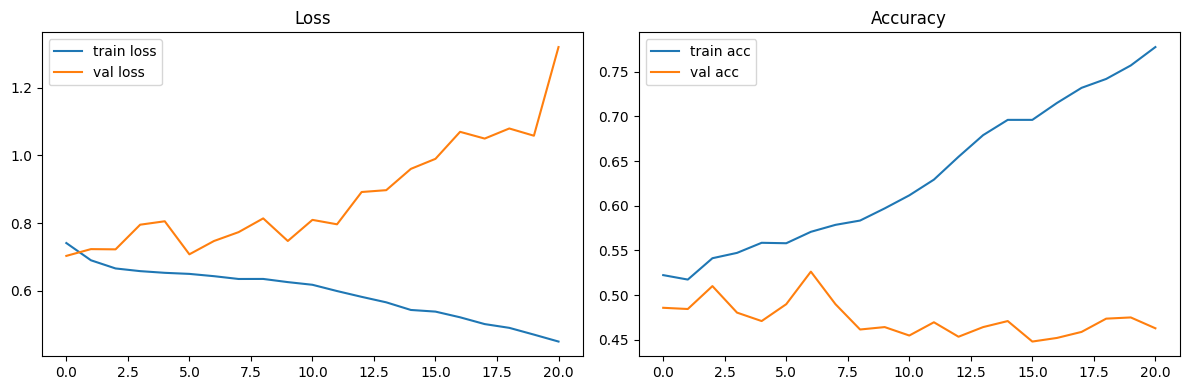

In [117]:
import matplotlib.pyplot as plt 
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(history.history['loss'],label='train loss')
axes[0].plot(history.history['val_loss'],label='val loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[1].plot(history.history['accuracy'],label='train acc')
axes[1].plot(history.history['val_accuracy'],label='val acc')
axes[1].set_title('Accuracy')
axes[1].legend()
plt.tight_layout()  
plt.show()

In [ ]:
# data=pd.DataFrame()
# start_date='2025-07-01T00:00:00'
# end_date='2026-04-15T21:30:00'
# api_url=f'https://api.twelvedata.com/{technical}?symbol={ticker}&order=asc&timezone={timezone}&start_date={start_date}&end_date={end_date}&interval={interval}&outputsize=5000&apikey={api_key}'
# fetch=requests.get(api_url).json()
# df=pd.DataFrame(fetch['values'])
# data=pd.concat([df,data])
# data

,datetime,open,high,low,close
0,2025-07-01 01:30:00,107751.68,107787.05,106944.55,107173.21
1,2025-07-01 05:30:00,107173.21,107579.3,107062,107221.44
2,2025-07-01 09:30:00,107221.44,107248.24,106659.96,107212.88
3,2025-07-01 13:30:00,107212.89,107212.89,106310.18,106639.08
4,2025-07-01 17:30:00,106639.94,107246.53,105635.14,105986.38
...,...,...,...,...,...
1728,2026-04-15 05:30:00,74176.09,74828.61,74149.45,74376.75
1729,2026-04-15 09:30:00,74376.75,74478.06,73545,73771.35
1730,2026-04-15 13:30:00,73771.35,74287.82,73706,74232.72
1731,2026-04-15 17:30:00,74232.73,74541.06,73604.79,73861.45


In [119]:
data=pd.read_csv('BTC_2025-26_4h.csv')

In [120]:
data['color']=np.where(data['close']>data['open'],1,0)
data['open']=pd.to_numeric(data['open'])
data['close']=pd.to_numeric(data['close'])
data['high']=pd.to_numeric(data['high'])
data['low']=pd.to_numeric(data['low'])
future_return=(data['close'].shift(-6)-data['close'])/data['close']
data['label']=np.where(future_return>0.002,1,np.where(future_return<-0.002,0,np.nan))
data['price_change']=data['close'].pct_change()
data['price_change_2']=data['close'].pct_change(2)
data['price_change_4']=data['close'].pct_change(4)
data['price_change_8']=data['close'].pct_change(8)
data['sma_5']=data['close'].rolling(5).mean()
data['sma_10']=data['close'].rolling(10).mean()
data['sma_20']=data['close'].rolling(20).mean()
data['close_to_sma5']=(data['close']-data['sma_5'])/data['sma_5']
data['close_to_sma10']=(data['close']-data['sma_10'])/data['sma_10']
data['close_to_sma20']=(data['close']-data['sma_20'])/data['sma_20']
period=10
data['atr_10']=calculate_atr(data,period)
period=20
data['atr_20']=calculate_atr(data,period)
data['ret_atr10']=data['price_change']/data['atr_10']
data['ret_atr20']=data['price_change']/data['atr_20']
data['volatility']=data['close'].rolling(10).std()
delta=data['close'].diff()
gain=(delta.where(delta>0,0)).rolling(14).mean()
loss=(-delta.where(delta<0,0)).rolling(14).mean()
rs=gain/(loss+1e-10)
data['rsi']=100-(100/(1+rs))
data['rsi_slope']=data['rsi']-data['rsi'].shift(3)
data=data.dropna()
data=data.reset_index(drop=True)
data[feature_cols]=scaler.transform(data[feature_cols])
X=[]
y=[]
for i in range(16,len(data)-16):
    seq=data[i-16:i][feature_cols].values
    label=data.iloc[i]['label']
    X.append(seq)
    y.append(label)
X=np.array(X)
y=np.array(y)
model.evaluate(X,y,verbose=0)

[0.7175611853599548, 0.4777998626232147]

In [121]:
from sklearn.metrics import classification_report,confusion_matrix,precision_recall_curve,accuracy_score,recall_score,precision_score
y_pred_proba=model.predict(X_test,verbose=0).flatten()
prec,rec,thresholds=precision_recall_curve(y_val,model.predict(X_val,verbose=0).flatten())
f1_scores=2*prec*rec/(prec+rec+1e-10)
best_threshold=thresholds[np.argmax(f1_scores)]
best_threshold

0.370461

In [122]:
y_pred=(y_pred_proba>0.5).astype(int)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.45      0.78      0.57       330
         1.0       0.58      0.24      0.34       412

    accuracy                           0.48       742
   macro avg       0.52      0.51      0.46       742
weighted avg       0.53      0.48      0.45       742



In [124]:
y_pred_proba=model.predict(X,verbose=0)
y_pred=(y_pred_proba>0.5).astype(int).flatten()
accuracy=accuracy_score(y,y_pred)
precision=precision_score(y,y_pred,zero_division=0)
recall=recall_score(y,y_pred,zero_division=0)
f1=2*(precision*recall)/(precision+recall+1e-10)
cm=confusion_matrix(y,y_pred)
print(accuracy,precision,recall,f1)
print(classification_report(y,y_pred))

0.4777998674618953 0.42702702702702705 0.1038107752956636 0.1670190274526805
              precision    recall  f1-score   support

         0.0       0.48      0.86      0.62       748
         1.0       0.43      0.10      0.17       761

    accuracy                           0.48      1509
   macro avg       0.46      0.48      0.39      1509
weighted avg       0.46      0.48      0.39      1509



In [39]:
confidence_bins=[(0.0,0.1),(0.1,0.2),(0.2,0.3),(0.3,0.4),(0.4,0.5),(0.5,0.6),(0.6,0.7),(0.7,0.8),(0.8,0.9),(0.9,1.0)]
print('Accuracy by Confidence Level:')
for low,high in confidence_bins:
    mask=(y_pred_proba>=low)&(y_pred_proba<high)
    if mask.sum()>0:
        conf_accuracy=accuracy_score(y[mask.flatten()],y_pred[mask.flatten()])
        print(f'{low:.2f}-{high:.2f}: {conf_accuracy:.4f} ({mask.sum()} predictions)')

Accuracy by Confidence Level:
0.30-0.40: 0.0000 (3 predictions)
0.40-0.50: 0.5025 (1007 predictions)
0.50-0.60: 0.4930 (428 predictions)
0.60-0.70: 0.5802 (81 predictions)
0.70-0.80: 0.8462 (13 predictions)


In [40]:
print(confusion_matrix(y,y_pred))

[[506 253]
 [504 269]]


In [125]:
model.save("models/rnn_model_4hrs.keras")

In [126]:
import joblib
joblib.dump(scaler,"scalers_4hrs/scaler.pkl")

['scalers_4hrs/scaler.pkl']